# Visualize track result

In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import torch
import pickle
import json

def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,dim=dim).cpu().numpy()


#### Load track data

In [3]:
dataset = 'simulation_data'
scenario = '4-1'
scenario = '2-1'
#datafolder = 'simulation_20250305_160930' # set the folder name
#datafolder = 'simulation_20250307_124152' # set the folder name
#datafolder = 'simulation_20250307_152801' # more epoch (400)
#datafolder = 'simulation_20250321_172821'
datafolder = 'simulation_20250828_232502'
#datafolder = 'simulation_20250304_143046' # set the folder name
nsample = 100 # number of generated sample
mode = "normalized" # "normalized" or "unnormalized"

path = './save/'+datafolder+'/generated_outputs_nsample' + str(nsample)  + f'_{mode}.pk' 
scenario_map = json.load(open(f"./data/{dataset}/Scenario{scenario}/scenario_map.json"))
with open(path, 'rb') as f:
    samples,all_target,all_evalpoint,all_observed,all_observed_time,scaler,mean_scaler = pickle.load( f)


# samples: original predictions

all_target_np = all_target.cpu().numpy() # observed value (ground truth)
all_evalpoint_np = all_evalpoint.cpu().numpy() # target mask
all_observed_np = all_observed.cpu().numpy() # observed mask
all_given_np = all_observed_np - all_evalpoint_np # the mask for the given data (used for imputation)

K = samples.shape[-1] #feature
L = samples.shape[-2] #time length

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(samples, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

In [4]:
gt_data = all_target_np
imputed_data = quantiles_imp[2] # 0.5 quantile(median of samples)
#imputed_data = samples.cpu().numpy()[:,10]
prediction_mask = all_observed_np[:,:,0] # observed mask
given_mask = all_given_np[:,:,0] # given mask

In [22]:
imputed_data.min()

np.float32(-2.5534892)

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_track(gt_data, imputed_data, prediction_mask, given_mask, track_idx, color, legend_entries):
    """
    Plots a single track with ground truth, observed points, and imputed predictions.
    """
    given_mask_track = given_mask[track_idx]
    prediction_mask_track = prediction_mask[track_idx]

    # Extract x and y coordinates
    x_gt = gt_data[track_idx, :, 0]  
    y_gt = gt_data[track_idx, :, 1]  
    x_obs = x_gt[given_mask_track == 1]  
    y_obs = y_gt[given_mask_track == 1]  
    x_pred = imputed_data[track_idx, :, 0]  
    y_pred = imputed_data[track_idx, :, 1]  

    # Only keep observed points
    x_gt = x_gt[prediction_mask_track == 1]
    y_gt = y_gt[prediction_mask_track == 1]
    x_pred = x_pred[prediction_mask_track == 1]
    y_pred = y_pred[prediction_mask_track == 1]

    # Plot predicted track
    plt.plot(x_pred, y_pred, color=color, linestyle='solid', label=f'Track {track_idx} (Predicted)')

    # Plot ground truth and observed points
    plt.scatter(x_gt, y_gt, color=color, marker='o', alpha=0.6, label=None)  

    # Handle observed points:
    if len(x_obs) == 1:
        plt.scatter(x_obs, y_obs, color='yellow', marker='x', label="Observed Point (First & Last)")
    elif len(x_obs) >= 2:
        plt.scatter(x_obs[0], y_obs[0], color='yellow', marker='x', label="Observed Point (start)" if "first" not in legend_entries else None)  # First point 🟡
        plt.scatter(x_obs[1:-1], y_obs[1:-1], color='green', marker='x', label="Observed Points (Middle)" if "middle" not in legend_entries else None)  # Middle points 🟢
        plt.scatter(x_obs[-1], y_obs[-1], color='red', marker='x', label="Observed Point (End)" if "last" not in legend_entries else None)  # Last point 🔴
        legend_entries.update(["first", "middle", "last"])


def draw_scenario(scenario_maps, legend_entries):
    """
    Draws all obstacles, ensuring unique legend entries.
    """
    if not scenario_maps:
        return

    print(scenario_maps)

    for obstacle in scenario_maps:
        print(obstacle)
        if "rectangle" in obstacle:
            rect = obstacle["rectangle"]
            x1, y1 = rect["p1"]
            x2, y2 = rect["p2"]
            label = "Obstacle (Rectangle)" if "rectangle" not in legend_entries else None
            plt.fill([x1, x2, x2, x1], [y1, y1, y2, y2], color='gray', alpha=0.5, label=label)
            legend_entries.add("rectangle")

        elif "standing_person" in obstacle:
            x, y = obstacle["standing_person"]
            label = "Standing Person" if "standing_person" not in legend_entries else None
            plt.scatter(x, y, color='black', marker='*', s=200, label=label)
            legend_entries.add("standing_person")

        elif "circle" in obstacle:
            circle_info = obstacle["circle"]
            center = circle_info["center"]
            radius = circle_info["radius"]
            label = "Obstacle (Circle)" if "circle" not in legend_entries else None
            circle = plt.Circle(center, radius, color='gray', alpha=0.5, label=label)
            plt.gca().add_patch(circle)
            legend_entries.add("circle")

        elif "wall" in obstacle:
            print("debug", obstacle)
            wall_points = obstacle["wall"]
            x_vals, y_vals = zip(*wall_points)
            label = "Wall" if "wall" not in legend_entries else None
            plt.plot(x_vals, y_vals, color='black', linestyle='-', linewidth=1, label=label)
            legend_entries.add("wall")

        elif "entrance" in obstacle:
            entrance = obstacle["entrance"]
            x1, y1 = entrance["p1"]
            x2, y2 = entrance["p2"]
            label = "Entrance" if "entrance" not in legend_entries else None
            plt.plot([x1, x2], [y1, y2], color='blue', linestyle='-', linewidth=5, label=label)
            legend_entries.add("entrance")


def visualize_all_tracks(gt_data, imputed_data, prediction_mask, given_mask, obstacles=None):
    """
    Plots all tracks along with obstacles.
    """
    plt.figure(figsize=(20, 5))
    plt.rcParams["font.size"] = 16

    num_tracks = gt_data.shape[0]  # Number of tracks
    #colors = plt.cm.get_cmap("tab10", num_tracks)  # Assign unique colors to each track
    colors = plt.get_cmap("tab10")  # Assign unique colors to each track
    legend_entries = set()  # Keep track of legend entries to avoid duplicates

    for track_idx in range(num_tracks):
        plot_track(gt_data, imputed_data, prediction_mask, given_mask, track_idx, colors(track_idx), legend_entries)

    draw_scenario(obstacles, legend_entries)

    # Set the axis limits
    plt.xlim(0, 84)  
    plt.ylim(6, 18)  

    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title("Multiple Tracks Visualization with Obstacles")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    plt.grid()
    plt.show()


def visualize_single_track(gt_data, imputed_data, prediction_mask, given_mask, track_idx, obstacles=None):
    """
    Plots a single track with obstacles.
    """
    plt.figure(figsize=(40, 5))
    plt.rcParams["font.size"] = 16

    #colors = plt.cm.get_cmap("tab10", 1)  # Single color for one track
    colors = plt.get_cmap("tab10")  # Assign unique colors to each track
    legend_entries = set()  # Keep track of legend entries

    plot_track(gt_data, imputed_data, prediction_mask, given_mask, track_idx, colors(0), legend_entries)
    draw_scenario(obstacles, legend_entries)

    # Set the axis limits
    plt.xlim(0, 84)  
    plt.ylim(6, 18)  

    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title(f"Track {track_idx} Visualization with Obstacles")
    plt.legend()
    plt.grid()
    plt.show()

{'obstacles': [], 'forbidden_area': [{'type': 'rectangle', 'p1': [0, 0], 'p2': [30, 30]}, {'type': 'rectangle', 'p1': [0, 38], 'p2': [22, 70]}, {'type': 'rectangle', 'p1': [30, 38], 'p2': [70, 70]}, {'type': 'rectangle', 'p1': [38, 0], 'p2': [70, 30]}], 'wall': [{'segment': [[0, 30], [30, 30]]}, {'segment': [[30, 30], [30, 0]]}, {'segment': [[30, 0], [38, 0]]}, {'segment': [[38, 0], [38, 30]]}, {'segment': [[38, 30], [70, 30]]}, {'segment': [[70, 30], [70, 38]]}, {'segment': [[70, 38], [30, 38]]}, {'segment': [[30, 38], [30, 70]]}, {'segment': [[30, 70], [22, 70]]}, {'segment': [[22, 70], [22, 38]]}, {'segment': [[22, 38], [0, 38]]}, {'segment': [[0, 38], [0, 30]]}], 'entrance': [{'p1': [0, 30], 'p2': [0, 38], 'goal_id': 2}, {'p1': [22, 70], 'p2': [30, 70], 'goal_id': 1}, {'p1': [70, 38], 'p2': [70, 30], 'goal_id': 4}, {'p1': [38, 0], 'p2': [30, 0], 'goal_id': 3}], 'position': {'p1': [0, 0], 'p2': [70, 70]}}
obstacles
forbidden_area
wall
debug wall


TypeError: string indices must be integers, not 'str'

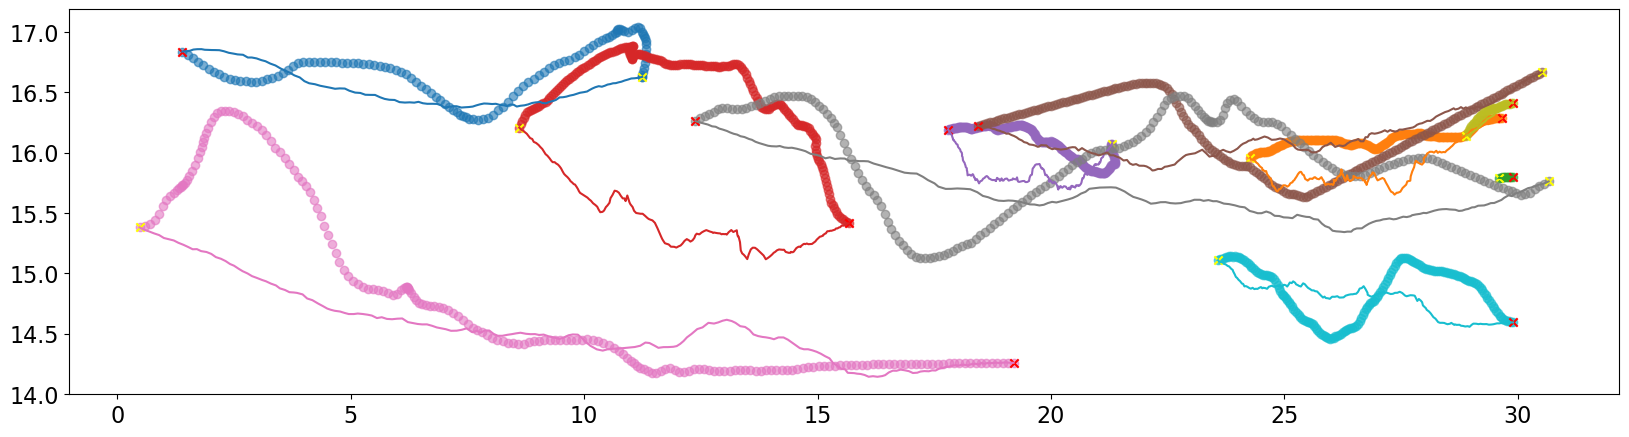

In [11]:
start_ind = 45
end_ind = 55
visualize_all_tracks(gt_data[start_ind:end_ind], imputed_data[start_ind:end_ind], prediction_mask[start_ind:end_ind], given_mask[start_ind:end_ind], scenario_map)

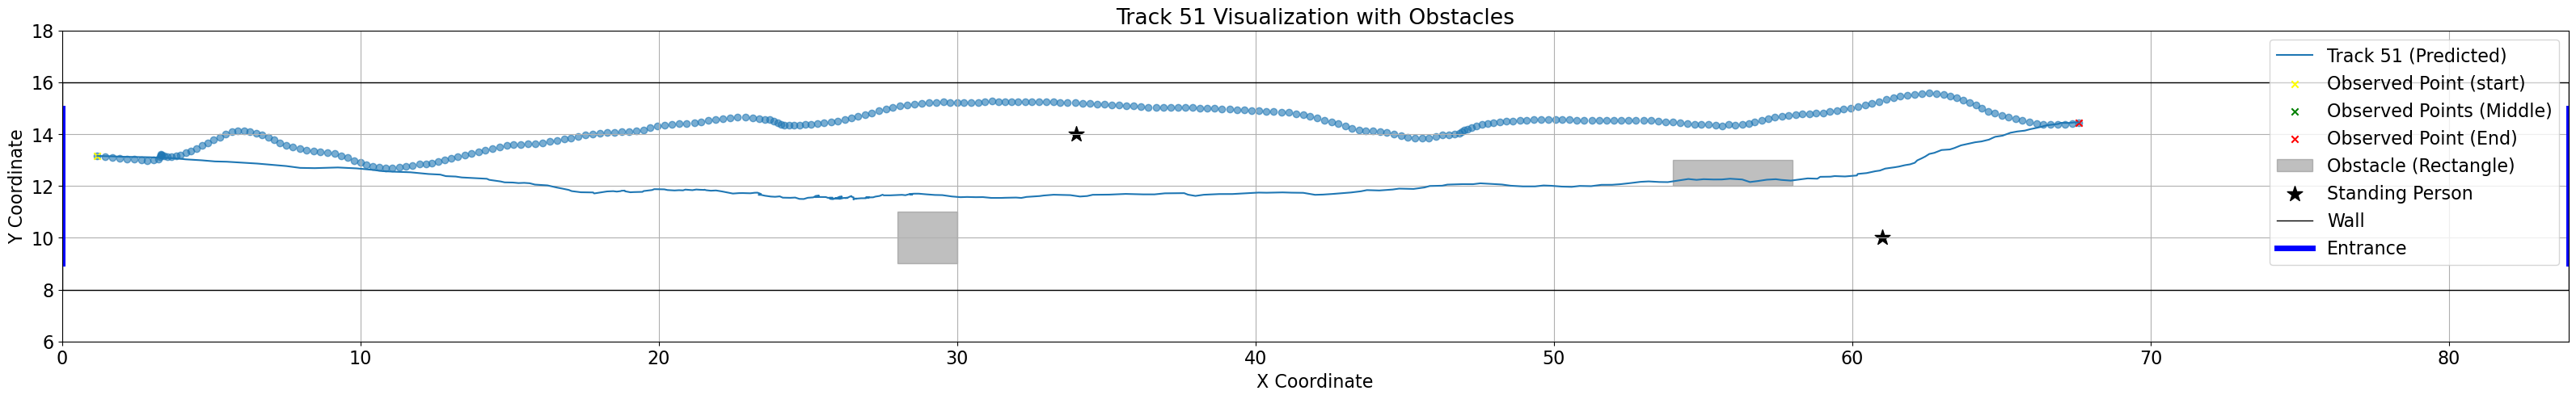

In [6]:
track_idx = 51
visualize_single_track(gt_data, imputed_data, prediction_mask, given_mask, track_idx, scenario_maps)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scenario_map import create_scenario_map_3channel

def visualize_tracks_on_map(gt_data, imputed_data, prediction_mask, given_mask, scenario, scale=10):
    """
    Visualizes multiple tracks overlayed on the scenario map.

    Args:
        gt_data (torch.Tensor): Ground truth track data (B, T, 2) in grid scale.
        imputed_data (torch.Tensor): Imputed (predicted) track data (B, T, 2) in grid scale.
        prediction_mask (torch.Tensor): Mask indicating valid ground truth data.
        given_mask (torch.Tensor): Mask indicating observed values.
        scenario (dict): Scenario definition containing obstacles, walls, etc.
        scale (int, optional): Scaling factor for resolution (default=10).
    """
    # Generate the scenario map (3-channel)
    scenario_map = create_scenario_map_3channel(scenario, scale=scale, draw_standing_person=False)
    #scale = 1.5

    # Convert the scenario map to RGB for matplotlib (from OpenCV's BGR)
    scenario_map = cv2.cvtColor(scenario_map, cv2.COLOR_BGR2RGB)

    # Get the height of the scenario map to flip Y-coordinates
    map_height = scenario_map.shape[0]  # Number of pixels in height
    map_width = scenario_map.shape[1]  # Number of pixels in width
    #map_height = 512  # Number of pixels in height
    #map_width = 512  # Number of pixels in width

    # Create the figure
    plt.figure(figsize=(30, 8))
    plt.imshow(scenario_map)  # Display scenario map as background

    num_tracks = gt_data.shape[0]  # Number of tracks
    colors = plt.cm.get_cmap("tab10", num_tracks)  # Unique colors for each track

    for track_idx in range(num_tracks):
        # Apply prediction_mask to gt_data
        valid_gt_mask = prediction_mask[track_idx] == 1

        # Scale GT and Predicted Data
        x_gt, y_gt = gt_data[track_idx, :, 0] * map_width, gt_data[track_idx, :, 1] * map_height
        x_pred, y_pred = imputed_data[track_idx, :, 0] * map_width, imputed_data[track_idx, :, 1] * map_height

        ## Flip Y-coordinates to match scenario map
        #y_gt_flipped = map_height - y_gt
        #y_pred_flipped = map_height - y_pred

        # Mask ground truth using prediction_mask
        x_gt_valid, y_gt_valid = x_gt[valid_gt_mask], y_gt[valid_gt_mask]

        # Plot the ground truth track (dashed line) only for valid data points
        plt.plot(x_gt_valid, y_gt_valid, color=colors(track_idx), linestyle='solid', label=f'Track {track_idx} (Ground Truth)')

        # Plot the predicted (imputed) track (solid line)
        plt.plot(x_pred, y_pred, color=colors(track_idx), linestyle='dashed', label=f'Track {track_idx} (Predicted)')

        # Identify observed points
        observed_mask = given_mask[track_idx]
        observed_indices = np.where((observed_mask == 1) & valid_gt_mask)[0]  # Ensure only valid points are used

        if len(observed_indices) >= 2:
            plt.scatter(x_gt[observed_indices[0]], y_gt[observed_indices[0]], color='yellow', marker='x', s=80, label="Observed Point (First)" if track_idx == 0 else None)
            plt.scatter(x_gt[observed_indices[1:-1]], y_gt[observed_indices[1:-1]], color='red', marker='x', s=40, label="Observed Points (Middle)" if track_idx == 0 else None)
            plt.scatter(x_gt[observed_indices[-1]], y_gt[observed_indices[-1]], color='green', marker='x', s=80, label="Observed Point (Last)" if track_idx == 0 else None)
        elif len(observed_indices) == 1:
            plt.scatter(x_gt[observed_indices[0]], y_gt[observed_indices[0]], color='yellow', marker='x', s=80, label="Observed Point (First & Last)")

    # Move legend outside for cleaner visualization
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.title("Tracks Overlaid on Scenario Map")
    plt.axis("off")  # Hide axis labels since we're working with a map
    plt.show()

/tmp/ipykernel_80784/3539918587.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_tracks)  # Unique colors for each track


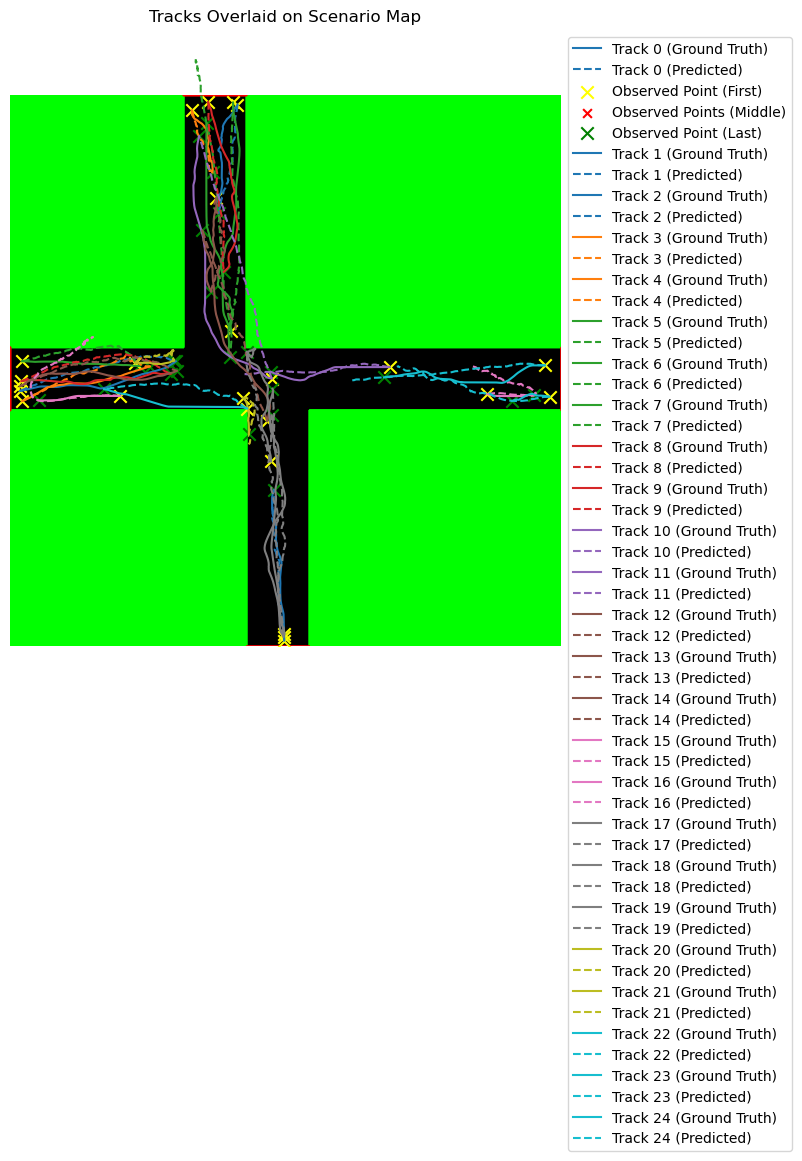

In [13]:
start_ind =2165
end_ind =2195
start_ind =600
end_ind =625
visualize_tracks_on_map(gt_data[start_ind:end_ind], imputed_data[start_ind:end_ind], prediction_mask[start_ind:end_ind], given_mask[start_ind:end_ind], scenario_map, scale=10)

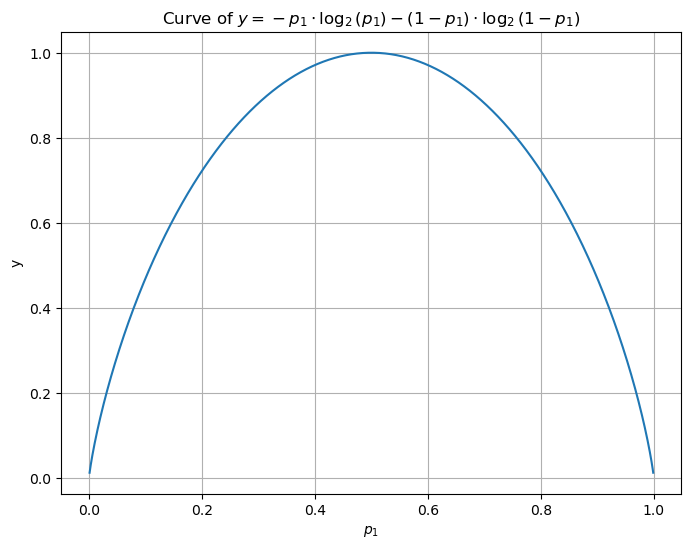

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values, avoiding zero since log2(0) is undefined
x = np.linspace(0.001, 0.999, 1000)  # Range from 0.01 to 10 with 400 points
y = -x * np.log2(x) - (1-x) * np.log2(1-x)  # Compute y = x * log2(x)

# Plotting the curve
plt.figure(figsize=(8, 6))
plt.plot(x, y)
plt.title(r'Curve of $y = -p_1 \cdot \log_2(p_1) - (1-p_1) \cdot \log_2(1-p_1)$')
plt.xlabel('$p_1$')
plt.ylabel('y')
plt.grid(True)
plt.show()